In [1]:
!pip install pandas numpy matplotlib statsmodels

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Nat_Gas.csv to Nat_Gas (1).csv


In [5]:
import pandas as pd

df = pd.read_csv("Nat_Gas.csv")

df.columns = ["Date", "Price"]
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")
df.set_index("Date", inplace=True)

df = df.asfreq('M')

df.head()

/tmp/ipykernel_2570/32476012.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])
/tmp/ipykernel_2570/32476012.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.asfreq('M')


,Price
Date,
2020-10-31,10.1
2020-11-30,10.3
2020-12-31,11.0
2021-01-31,10.9
2021-02-28,10.9


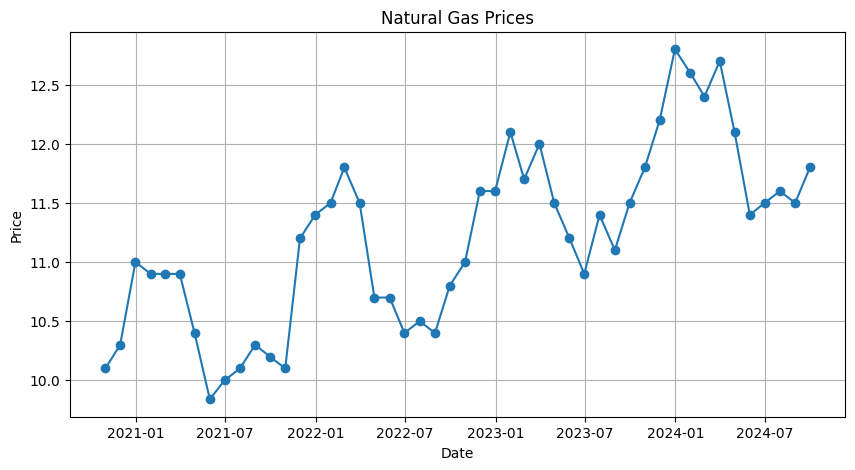

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df.index, df["Price"], marker='o')
plt.title("Natural Gas Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    df["Price"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Price   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                   1.581
Date:                            Mon, 30 Mar 2026   AIC                              6.838
Time:                                    06:57:20   BIC                             12.061
Sample:                                10-31-2020   HQIC                             7.972
                                     - 09-30-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4532      0.301     -1.505      0.132      -1.044       0.137
ma.L1         -0.5152      0.344   

In [8]:
forecast_steps = 12
forecast = results.get_forecast(steps=forecast_steps)

forecast_index = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=forecast_steps,
    freq='M'
)

forecast_series = pd.Series(
    forecast.predicted_mean.values,
    index=forecast_index
)

/tmp/ipykernel_2570/2794123855.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(


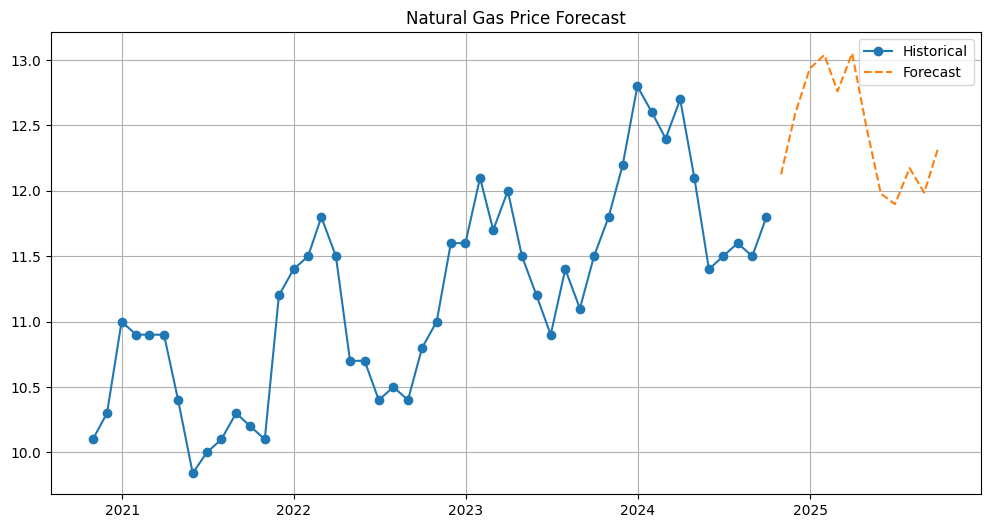

In [9]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Price"], label="Historical", marker='o')
plt.plot(forecast_series.index, forecast_series,
         label="Forecast", linestyle='--')

plt.legend()
plt.title("Natural Gas Price Forecast")
plt.grid()
plt.show()

In [10]:
import numpy as np

full_series = pd.concat([df["Price"], forecast_series])

def estimate_price(date_str):
    date = pd.to_datetime(date_str)

    # exact match
    if date in full_series.index:
        return float(full_series.loc[date])

    # interpolation
    full_series_sorted = full_series.sort_index()

    return float(np.interp(
        date.value,
        full_series_sorted.index.view(np.int64),
        full_series_sorted.values
    ))

In [11]:
print("Past:", estimate_price("2022-05-15"))
print("Future:", estimate_price("2025-04-10"))

Past: 10.7
Future: 12.866350615447697


In [12]:
print(uploaded.keys())

dict_keys(['Nat_Gas (1).csv'])


In [13]:
df.isna().sum()

,0
Price,0


In [14]:
df["Price"] = df["Price"].interpolate()